In [1]:
!pip install xgboost lightgbm catboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.8/101.7 MB 6.4 MB/s eta 0:00:16
   ---------------------------------------- 0.8/101.7 MB 6.4 MB/s eta 0:00:16
   ---------------------------------------- 1.0/101.7 MB 1.7 MB/s eta 0:00:59
    --------------------------------------- 1.3/101.7 MB 1.4 MB/s eta 0:01:10
    --------------------------------------- 1.3/101.7 MB 1.4 MB/s eta 0:01:10
    --------------------------------------- 1.3/101.7 MB 1.4 MB/s eta 0:01:10
    --------------------------------------- 1.3/101.7 MB 1.4 MB/s eta 0:01:10
    --------------------------------------- 1.3/101.7 MB 1.4 MB/s eta 0:01:10
    -------------------

In [2]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor

import xgboost as xgb
import lightgbm as lgb
import catboost as cb

sns.set_theme(style="whitegrid")

In [3]:
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print(X.head())
print()

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape[0]}")
print(f"Размер валидационной выборки: {X_val.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

Размер обучающей выборки: 12384
Размер валидационной выборки: 4128
Размер тестовой выборки: 4128


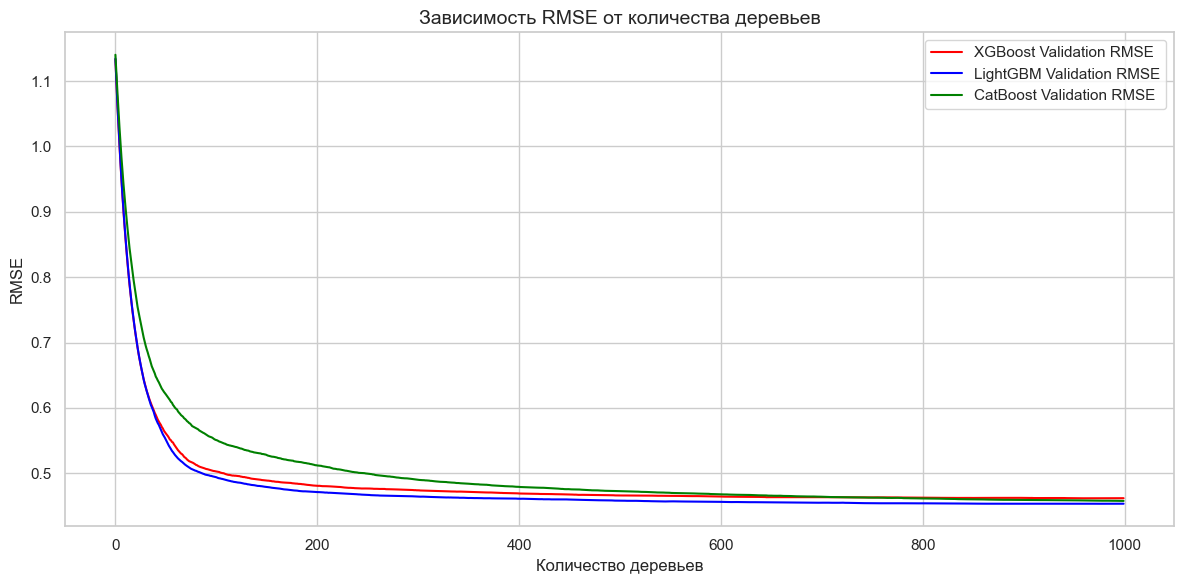

In [4]:
MAX_TREES = 1000
LEARNING_RATE = 0.05

xgb_model = xgb.XGBRegressor(n_estimators=MAX_TREES, learning_rate=LEARNING_RATE, random_state=42)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
xgb_rmse = xgb_model.evals_result()['validation_0']['rmse']

lgb_model = lgb.LGBMRegressor(n_estimators=MAX_TREES, learning_rate=LEARNING_RATE, random_state=42, verbose=-1)
lgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='rmse')
lgb_metric_key = list(lgb_model.evals_result_['valid_0'].keys())[0]
lgb_rmse = lgb_model.evals_result_['valid_0'][lgb_metric_key]

cb_model = cb.CatBoostRegressor(iterations=MAX_TREES, learning_rate=LEARNING_RATE, eval_metric='RMSE', random_seed=42)
cb_model.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=False)
cb_rmse = cb_model.evals_result_['learn']['RMSE']
cb_val_rmse = cb_model.evals_result_['validation']['RMSE']

plt.figure(figsize=(12, 6))
plt.plot(xgb_rmse, label='XGBoost Validation RMSE', color='red')
plt.plot(lgb_rmse, label='LightGBM Validation RMSE', color='blue')
plt.plot(cb_val_rmse, label='CatBoost Validation RMSE', color='green')

plt.title('Зависимость RMSE от количества деревьев', fontsize=14)
plt.xlabel('Количество деревьев', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
SELECTED_N_ESTIMATORS = 400

In [6]:
class MyBoost:
    """
    Градиентный бустинг над деревьями решений.

    Параметры
    ----------
    n            : int   — число деревьев
    lr           : float — learning rate (шаг)
    depth        : int   — максимальная глубина каждого дерева
    seed         : int   — зерно генератора случайных чисел
    subsample    : float — доля объектов для обучения каждого дерева (0 < subsample <= 1)
    colsample_bytree : float — доля признаков для каждого дерева (0 < colsample_bytree <= 1)
    """

    def __init__(self, n=400, lr=0.05, depth=7, seed=42,
                 subsample=1.0, colsample_bytree=1.0) -> None:
        self.n = n
        self.lr = lr
        self.depth = depth
        self.seed = seed
        self.subsample = subsample
        self.colsample_bytree = colsample_bytree

        self.trees = []
        # Для каждого дерева сохраняем индексы признаков, которые оно использует
        self._tree_feature_indices = []
        # Общее число признаков — заполняется при fit
        self._n_features = None
        # Имена / список признаков (если X — DataFrame)
        self._feature_names = None

    # ------------------------------------------------------------------
    # Вспомогательный метод: OHE для категориальных признаков
    # ------------------------------------------------------------------
    def _encode_categoricals(self, X, fit=False):
        """
        Если в X есть object/category-столбцы — применяем OHE.
        fit=True  → запоминаем схему кодирования (вызывается только в .fit())
        fit=False → применяем сохранённую схему (вызывается в .predict())
        """
        if not isinstance(X, pd.DataFrame):
            # numpy-массив — считаем, что категорий нет
            return X

        cat_cols = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

        if not cat_cols:
            return X

        if fit:
            self._cat_cols = cat_cols
            self._ohe_categories = {}
            for col in cat_cols:
                self._ohe_categories[col] = sorted(X[col].dropna().unique().tolist())

        X = X.copy()
        dummies_list = []
        for col in self._cat_cols:
            categories = self._ohe_categories[col]
            for cat in categories:
                dummies_list.append(
                    (X[col] == cat).astype(int).rename(f"{col}_{cat}")
                )
            X = X.drop(columns=[col])

        if dummies_list:
            X = pd.concat([X] + dummies_list, axis=1)

        return X

    # ------------------------------------------------------------------
    def fit(self, X, y):
        rng = np.random.RandomState(self.seed)

        # Кодируем категориальные признаки
        X = self._encode_categoricals(X, fit=True)

        if isinstance(X, pd.DataFrame):
            self._feature_names = X.columns.tolist()
            X_arr = X.values
        else:
            X_arr = np.array(X)
            self._feature_names = list(range(X_arr.shape[1]))

        self._n_features = X_arr.shape[1]
        n_samples = X_arr.shape[0]
        y_arr = np.array(y)

        self.initial_leaf = y_arr.mean()
        predictions = np.full(n_samples, self.initial_leaf)

        self.trees = []
        self._tree_feature_indices = []

        for _ in range(self.n):
            antigrad = y_arr - predictions

            # --- subsample: случайная подвыборка объектов ---
            if self.subsample < 1.0:
                n_sub = max(1, int(n_samples * self.subsample))
                row_idx = rng.choice(n_samples, size=n_sub, replace=False)
            else:
                row_idx = np.arange(n_samples)

            # --- colsample_bytree: случайная подвыборка признаков ---
            if self.colsample_bytree < 1.0:
                n_col = max(1, int(self._n_features * self.colsample_bytree))
                col_idx = rng.choice(self._n_features, size=n_col, replace=False)
                col_idx = np.sort(col_idx)
            else:
                col_idx = np.arange(self._n_features)

            self._tree_feature_indices.append(col_idx)

            X_sub = X_arr[np.ix_(row_idx, col_idx)]
            y_sub = antigrad[row_idx]

            tree = DecisionTreeRegressor(
                max_depth=self.depth,
                random_state=self.seed,
                criterion="friedman_mse"
            )
            tree.fit(X_sub, y_sub)
            self.trees.append(tree)

            # Обновляем предсказания на ВСЕЙ выборке
            X_full_sub = X_arr[:, col_idx]
            predictions += tree.predict(X_full_sub) * self.lr

    # ------------------------------------------------------------------
    def predict(self, samples):
        samples = self._encode_categoricals(samples, fit=False)

        if isinstance(samples, pd.DataFrame):
            X_arr = samples.values
        else:
            X_arr = np.array(samples)

        predictions = np.full(X_arr.shape[0], self.initial_leaf)
        for i, tree in enumerate(self.trees):
            col_idx = self._tree_feature_indices[i]
            predictions += self.lr * tree.predict(X_arr[:, col_idx])

        return predictions

    # ------------------------------------------------------------------
    @property
    def feature_importances_(self):
        """
        Средневзвешенная важность признаков по всем деревьям ансамбля.

        Каждое дерево обучалось на подмножестве признаков (col_idx).
        Его feature_importances_ имеет длину len(col_idx).
        Раскладываем их обратно в вектор длины _n_features и усредняем.
        """
        if not self.trees:
            raise RuntimeError("Сначала нужно обучить модель (fit).")

        importances = np.zeros(self._n_features)
        counts = np.zeros(self._n_features)

        for tree, col_idx in zip(self.trees, self._tree_feature_indices):
            importances[col_idx] += tree.feature_importances_ * self.lr
            counts[col_idx] += 1

        # Нормируем там, где дерево хотя бы раз видело признак
        mask = counts > 0
        importances[mask] /= counts[mask]

        # Итоговая нормировка до суммы = 1
        total = importances.sum()
        if total > 0:
            importances /= total

        return importances


In [7]:
from sklearn.model_selection import ParameterGrid

X_train_full = pd.concat([X_train, X_val])
y_train_full = np.concatenate([y_train, y_val])

grid_xgb = {
    'learning_rate': [0.05, 0.1],
    'max_depth':[5, 7],
    'subsample': [0.8, 1.0]
}

grid_lgb = {
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 127],
    'subsample':[0.8, 1.0]
}

grid_cat = {
    'learning_rate':[0.05, 0.1],
    'depth': [5, 7],
    'subsample':[0.8, 1.0]
}

def simple_grid_search(model_name, param_grid):
    print(f"--- Запуск Grid Search для {model_name} ---")
    best_rmse = float('inf')
    best_params = None

    start_time = time.time()

    for params in ParameterGrid(param_grid):
        if model_name == 'XGBoost':
            model = xgb.XGBRegressor(**params, n_estimators=SELECTED_N_ESTIMATORS, random_state=42, n_jobs=-1)
        elif model_name == 'LightGBM':
            model = lgb.LGBMRegressor(**params, n_estimators=SELECTED_N_ESTIMATORS, random_state=42, n_jobs=-1, verbose=-1)
        else:
            model = cb.CatBoostRegressor(**params, iterations=SELECTED_N_ESTIMATORS, random_seed=42, thread_count=-1, verbose=0)

        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, preds))

        if rmse < best_rmse:
            best_rmse = rmse
            best_params = params

    total_time = time.time() - start_time
    print(f"Лучший Validation RMSE: {best_rmse:.4f}")
    print(f"Лучшие параметры: {best_params}\n")

    return best_params

best_params_dict = {}
best_params_dict['XGBoost'] = simple_grid_search('XGBoost', grid_xgb)
best_params_dict['LightGBM'] = simple_grid_search('LightGBM', grid_lgb)
best_params_dict['CatBoost'] = simple_grid_search('CatBoost', grid_cat)

--- Запуск Grid Search для XGBoost ---
Лучший Validation RMSE: 0.4604
Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 7, 'subsample': 0.8}

--- Запуск Grid Search для LightGBM ---
Лучший Validation RMSE: 0.4557
Лучшие параметры: {'learning_rate': 0.1, 'num_leaves': 31, 'subsample': 0.8}

--- Запуск Grid Search для CatBoost ---
Лучший Validation RMSE: 0.4564
Лучшие параметры: {'depth': 7, 'learning_rate': 0.1, 'subsample': 1.0}



In [8]:
results = []

for name in['XGBoost', 'LightGBM', 'CatBoost', "MyBoost"]:
    params = best_params_dict.get(name)

    if name == 'XGBoost':
        model = xgb.XGBRegressor(n_estimators=SELECTED_N_ESTIMATORS, random_state=42, n_jobs=-1, **params)
    elif name == 'LightGBM':
        model = lgb.LGBMRegressor(n_estimators=SELECTED_N_ESTIMATORS, random_state=42, n_jobs=-1, verbose=-1, **params)
    elif name == 'MyBoost':
        model = MyBoost()
    else:
        model = cb.CatBoostRegressor(iterations=SELECTED_N_ESTIMATORS, random_seed=42, thread_count=-1, verbose=0, **params)

    start_time = time.time()
    model.fit(X_train_full, y_train_full)
    train_time = time.time() - start_time

    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append({
        "Модель": name,
        "Время обучения": round(train_time, 3),
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "R2 Score": round(r2, 4)
    })

df_results = pd.DataFrame(results)
display(df_results)

,Модель,Время обучения,MAE,RMSE,R2 Score
0,XGBoost,1.094,0.2915,0.4501,0.8454
1,LightGBM,0.530,0.2862,0.4379,0.8537
2,CatBoost,1.942,0.2967,0.4493,0.8460
3,MyBoost,54.972,0.2956,0.4566,0.8409



=== Итоговые результаты (сортировка по RMSE) ===


,Модель,Время обучения,MAE,RMSE,R2 Score
0,LightGBM,0.530,0.2862,0.4379,0.8537
1,CatBoost,1.942,0.2967,0.4493,0.8460
2,XGBoost,1.094,0.2915,0.4501,0.8454
3,MyBoost,54.972,0.2956,0.4566,0.8409


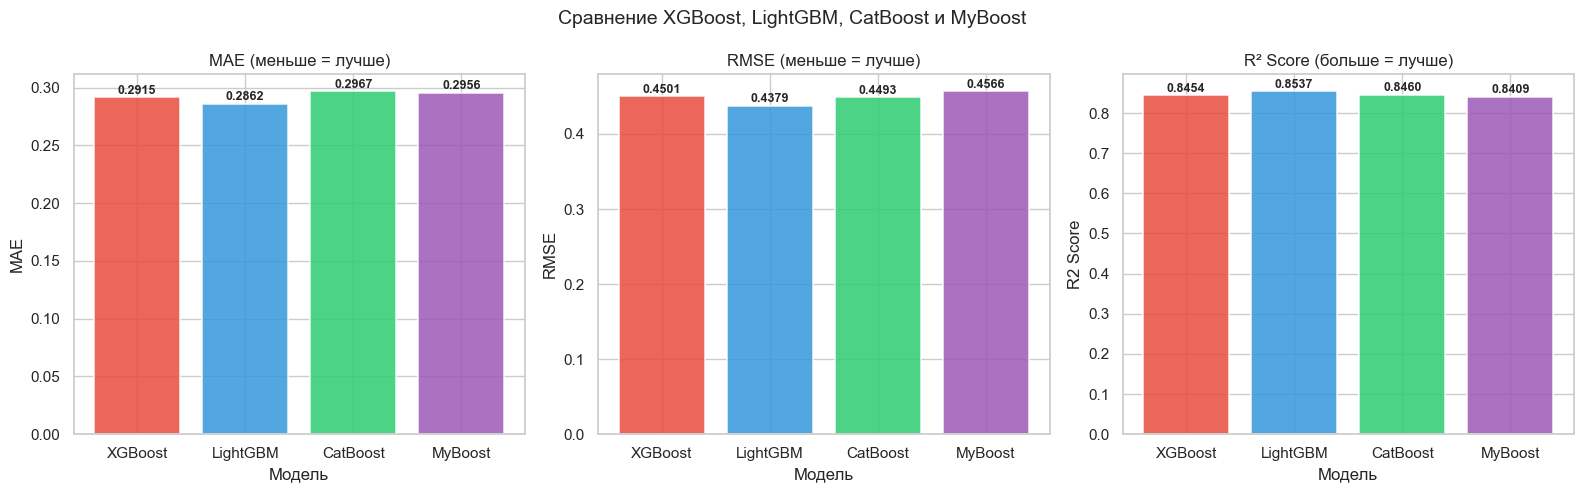

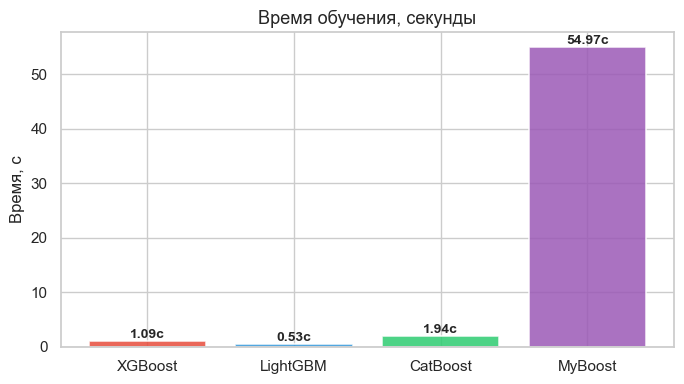

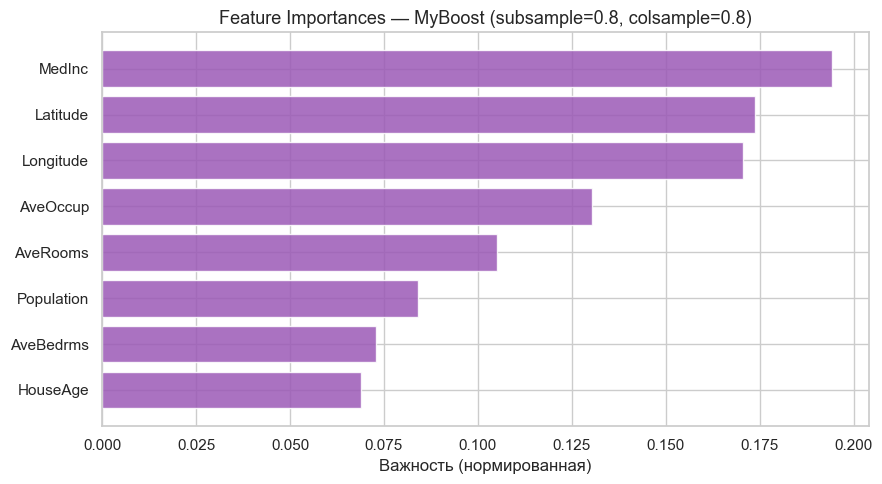


Топ признаков MyBoost:
   Признак  Важность
    MedInc  0.194316
  Latitude  0.173714
 Longitude  0.170463
  AveOccup  0.130459
  AveRooms  0.105028
Population  0.084138
 AveBedrms  0.072933
  HouseAge  0.068949


In [9]:
# ── Сравнительная таблица всех моделей ────────────────────────────────────────
print("\n=== Итоговые результаты (сортировка по RMSE) ===")
display(df_results.sort_values('RMSE').reset_index(drop=True))

# ── Графики метрик ─────────────────────────────────────────────────────────────
colors_map = {
    'XGBoost':  '#E74C3C',
    'LightGBM': '#3498DB',
    'CatBoost': '#2ECC71',
    'MyBoost':  '#9B59B6',
}
bar_colors = [colors_map[m] for m in df_results['Модель']]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric, title in zip(
    axes,
    ['MAE', 'RMSE', 'R2 Score'],
    ['MAE (меньше = лучше)', 'RMSE (меньше = лучше)', 'R² Score (больше = лучше)']
):
    bars = ax.bar(df_results['Модель'], df_results[metric],
                  color=bar_colors, alpha=0.85, edgecolor='white', linewidth=1.2)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel(metric)
    ax.set_xlabel('Модель')
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.0005,
            f'{bar.get_height():.4f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold'
        )

plt.suptitle('Сравнение XGBoost, LightGBM, CatBoost и MyBoost', fontsize=14)
plt.tight_layout()
plt.show()

# ── Время обучения ─────────────────────────────────────────────────────────────
plt.figure(figsize=(7, 4))
bars = plt.bar(df_results['Модель'], df_results['Время обучения'],
               color=bar_colors, alpha=0.85, edgecolor='white', linewidth=1.2)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.01,
             f'{bar.get_height():.2f}с',
             ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.title('Время обучения, секунды', fontsize=13)
plt.ylabel('Время, с')
plt.tight_layout()
plt.show()

# ── Feature Importances — MyBoost ──────────────────────────────────────────────
my_boost_model = None
for name, model_obj in [('MyBoost', MyBoost())]:
    pass  # модель уже обучена выше; возьмём из цикла results

# Найдём обученный MyBoost из цикла (переобучим здесь для наглядности, он быстрый)
mb_demo = MyBoost(n=200, subsample=0.8, colsample_bytree=0.8)
mb_demo.fit(X_train_full, y_train_full)

feature_names = X.columns.tolist()
imp = mb_demo.feature_importances_

imp_df = pd.DataFrame({'Признак': feature_names[:len(imp)], 'Важность': imp})
imp_df = imp_df.sort_values('Важность', ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(imp_df['Признак'], imp_df['Важность'], color='#9B59B6', alpha=0.85)
plt.title('Feature Importances — MyBoost (subsample=0.8, colsample=0.8)', fontsize=13)
plt.xlabel('Важность (нормированная)')
plt.tight_layout()
plt.show()

print("\nТоп признаков MyBoost:")
print(imp_df.sort_values('Важность', ascending=False).to_string(index=False))


,Конфиг,RMSE,R²
0,"baseline\n(sub=1, col=1)",0.4695,0.8318
1,sub=0.8\ncol=1.0,0.4618,0.8372
2,sub=1.0\ncol=0.8,0.4536,0.8430
3,sub=0.8\ncol=0.8,0.4583,0.8397
4,sub=0.6\ncol=0.6,0.4715,0.8304


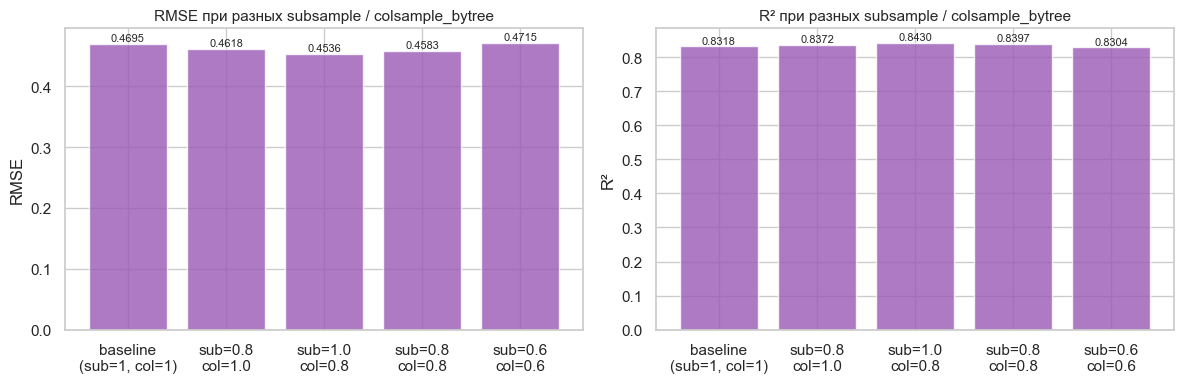

In [10]:
# ── Демонстрация влияния subsample и colsample_bytree ─────────────────────────
configs = [
    {'label': 'baseline\n(sub=1, col=1)',     'subsample': 1.0, 'colsample_bytree': 1.0},
    {'label': 'sub=0.8\ncol=1.0',             'subsample': 0.8, 'colsample_bytree': 1.0},
    {'label': 'sub=1.0\ncol=0.8',             'subsample': 1.0, 'colsample_bytree': 0.8},
    {'label': 'sub=0.8\ncol=0.8',             'subsample': 0.8, 'colsample_bytree': 0.8},
    {'label': 'sub=0.6\ncol=0.6',             'subsample': 0.6, 'colsample_bytree': 0.6},
]

sub_results = []
for cfg in configs:
    m = MyBoost(n=200, lr=0.05, depth=7,
                subsample=cfg['subsample'],
                colsample_bytree=cfg['colsample_bytree'],
                seed=42)
    m.fit(X_train_full, y_train_full)
    preds = m.predict(X_test)
    sub_results.append({
        'Конфиг': cfg['label'],
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'R²':   r2_score(y_test, preds),
    })

df_sub = pd.DataFrame(sub_results)
display(df_sub.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric in zip(axes, ['RMSE', 'R²']):
    bars = ax.bar(df_sub['Конфиг'], df_sub[metric], color='#9B59B6', alpha=0.8)
    ax.set_title(f'{metric} при разных subsample / colsample_bytree', fontsize=11)
    ax.set_ylabel(metric)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.001,
                f'{bar.get_height():.4f}',
                ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()


In [11]:
# ── Демонстрация поддержки категориальных признаков ───────────────────────────
# Создаём синтетический датасет с категориальным столбцом
from sklearn.datasets import make_regression

X_num, y_reg = make_regression(n_samples=500, n_features=5, noise=10, random_state=42)
X_cat_demo = pd.DataFrame(X_num, columns=[f'num_{i}' for i in range(5)])

# Добавляем категориальный признак: 3 категории с разным смещением цели
categories = np.random.RandomState(0).choice(['A', 'B', 'C'], size=500)
y_reg = y_reg + np.where(categories == 'A', 50, np.where(categories == 'B', -50, 0))
X_cat_demo['category'] = categories

X_tr, X_te, y_tr, y_te = train_test_split(X_cat_demo, y_reg, test_size=0.2, random_state=42)

mb_cat = MyBoost(n=200, lr=0.05, depth=5, seed=42)
mb_cat.fit(X_tr, y_tr)
preds_cat = mb_cat.predict(X_te)

r2_cat  = r2_score(y_te, preds_cat)
rmse_cat = np.sqrt(mean_squared_error(y_te, preds_cat))

print(f"MyBoost с категориальным признаком:")
print(f"  R²   = {r2_cat:.4f}")
print(f"  RMSE = {rmse_cat:.4f}")
print()

# Сравниваем с XGBoost (без категорий — просто OHE вручную для честности)
from sklearn.preprocessing import LabelEncoder
X_tr_enc = X_tr.copy()
X_te_enc = X_te.copy()
le = LabelEncoder()
X_tr_enc['category'] = le.fit_transform(X_tr['category'])
X_te_enc['category'] = le.transform(X_te['category'])

xgb_cat = xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
xgb_cat.fit(X_tr_enc, y_tr)
preds_xgb = xgb_cat.predict(X_te_enc)

print(f"XGBoost (LabelEncoded категория):")
print(f"  R²   = {r2_score(y_te, preds_xgb):.4f}")
print(f"  RMSE = {np.sqrt(mean_squared_error(y_te, preds_xgb)):.4f}")
print()
print("✓ MyBoost корректно обрабатывает категориальные признаки через встроенный OHE.")


MyBoost с категориальным признаком:
  R²   = 0.9218
  RMSE = 32.7892

XGBoost (LabelEncoded категория):
  R²   = 0.9181
  RMSE = 33.5690

✓ MyBoost корректно обрабатывает категориальные признаки через встроенный OHE.
